# 02: Weekly Seasonality Analysis
This notebook analyzes Wikipedia's usage patterns based on the day of the week, focusing on identifying the typical usage profile and the evolution of the Weekend-to-Weekday traffic ratio from 2015 to 2025.

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import numpy as np

# Add src to path
sys.path.append(os.path.abspath('../../'))
from src.data_prep import clean_pageview_data, add_time_features

# Configuration
DATA_PATH = '../../data/raw/en_wiki_pageviews_daily.csv'
REPORT_DIR = '../../reports/'
os.makedirs(REPORT_DIR, exist_ok=True)

sns.set_theme(style="whitegrid")
PURPLE_COLOR = '#800080'

## 1. Data Loading and Preparation

In [15]:
df = pd.read_csv(DATA_PATH)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = clean_pageview_data(df)
df = add_time_features(df)

# Ensure correct weekday ordering for plots and analysis
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['day_of_week'] = pd.Categorical(df['day_of_week'], categories=day_order, ordered=True)

print(f"Data loaded from {DATA_PATH}")
df.head()

Data loaded from ../../data/raw/en_wiki_pageviews_daily.csv


,timestamp,views,day_of_week,month_name,year,is_weekend
0,2015-07-01,243497551,Wednesday,July,2015,False
1,2015-07-02,241866978,Thursday,July,2015,False
2,2015-07-03,226919786,Friday,July,2015,False
3,2015-07-04,226583272,Saturday,July,2015,True
4,2015-07-05,240912348,Sunday,July,2015,True


## 2. Weekly Usage Profile
Goal: understand typical traffic by day of week.

C:\Users\preet\AppData\Local\Temp\ipykernel_13100\4028616843.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weekly_profile = df.groupby('day_of_week')['views'].mean().reset_index()
C:\Users\preet\AppData\Local\Temp\ipykernel_13100\4028616843.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=weekly_profile, x='day_of_week', y='views', palette='viridis')


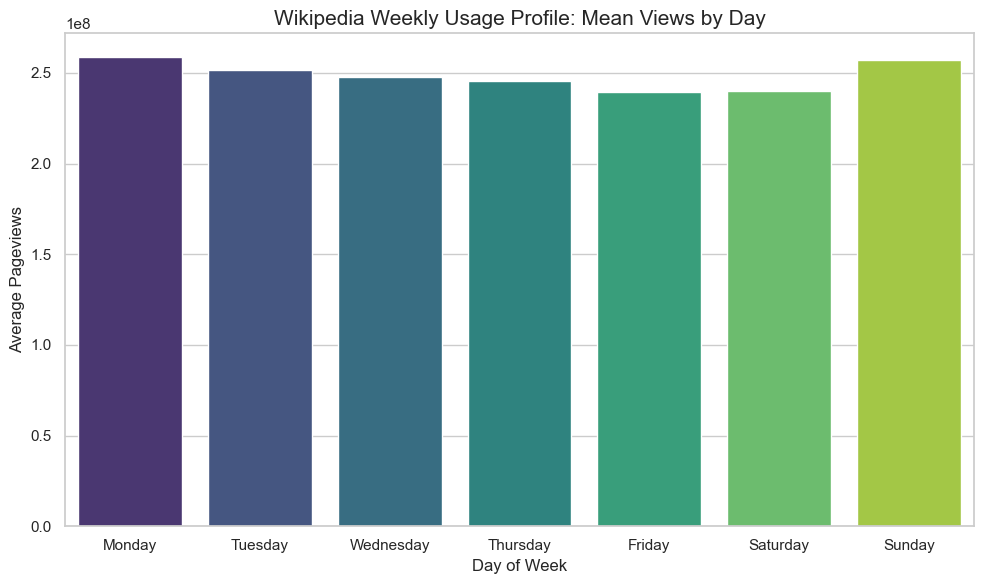

In [16]:
# Compute mean views for each day
weekly_profile = df.groupby('day_of_week')['views'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=weekly_profile, x='day_of_week', y='views', palette='viridis')
plt.title('Wikipedia Weekly Usage Profile: Mean Views by Day', fontsize=15)
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Average Pageviews', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, 'section_2_weekly_profile_bars.png'))
plt.show()

## 3. Annual Weekend vs Weekday Analysis
Goal: measure behavioral difference over time.

In [17]:
# Group by year and is_weekend to get mean views
annual_ratios = df.groupby(['year', 'is_weekend'])['views'].mean().unstack()
annual_ratios.columns = ['weekday_mean', 'weekend_mean']

# Calculate the ratio: Weekend / Weekday
annual_ratios['ratio'] = annual_ratios['weekend_mean'] / annual_ratios['weekday_mean']

print("Yearly Weekend vs Weekday Ratio Table:")
print(annual_ratios[['weekday_mean', 'weekend_mean', 'ratio']])

Yearly Weekend vs Weekday Ratio Table:
      weekday_mean  weekend_mean     ratio
year                                      
2015  2.520347e+08  2.391153e+08  0.948740
2016  2.576201e+08  2.459694e+08  0.954776
2017  2.533965e+08  2.431072e+08  0.959394
2018  2.538927e+08  2.478650e+08  0.976259
2019  2.532425e+08  2.504728e+08  0.989063
2020  2.558809e+08  2.622333e+08  1.024826
2021  2.424813e+08  2.468591e+08  1.018054
2022  2.360390e+08  2.402258e+08  1.017738
2023  2.487774e+08  2.554171e+08  1.026689
2024  2.484409e+08  2.541785e+08  1.023094
2025  2.337006e+08  2.404420e+08  1.028847


In [18]:
df['views'].describe()

count    3.807000e+03
mean     2.485418e+08
std      1.675946e+07
min      2.028450e+08
25%      2.369918e+08
50%      2.476179e+08
75%      2.585869e+08
max      3.300912e+08
Name: views, dtype: float64

In [19]:
df.shape

(3807, 6)

## 4. Main Visualization: Weekend-to-Weekday Ratio Trend

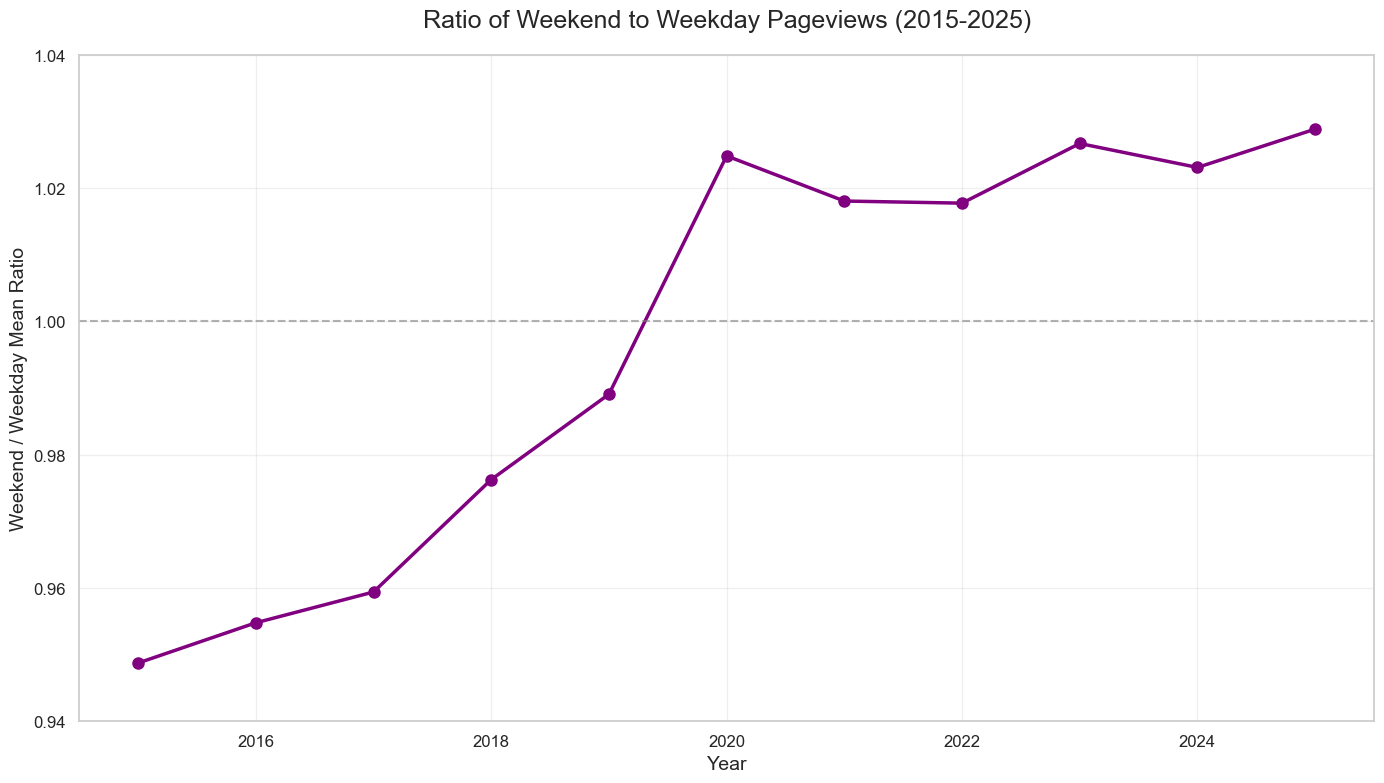

In [20]:
plt.figure(figsize=(14, 8))

# Plot the ratio line
plt.plot(annual_ratios.index, annual_ratios['ratio'], marker='o', linestyle='-', color=PURPLE_COLOR, linewidth=2.5, markersize=8)

# Add horizontal reference line at 1.0
plt.axhline(y=1.0, color='gray', linestyle='--', alpha=0.6, label='Equal Weekend/Weekday Traffic')

# Formatting
plt.title('Ratio of Weekend to Weekday Pageviews (2015-2025)', fontsize=18, pad=20)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Weekend / Weekday Mean Ratio', fontsize=14)
plt.ylim(0.94, 1.04) 
plt.grid(True, which='both', linestyle='-', alpha=0.3)
plt.tick_params(labelsize=12)

plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, 'section_2_weekend_weekday_ratio.png'), dpi=300)
plt.show()

## 5. Stability Check (Variance per Weekday)

In [21]:
# Calculate standard deviation and Coefficient of Variation (CV) for daily views per weekday
stability = df.groupby('day_of_week')['views'].agg(['mean', 'std']).reset_index()
stability['cv'] = stability['std'] / stability['mean']

print("Stability Check: Variation per Weekday (CV = Std / Mean)")
print(stability)

Stability Check: Variation per Weekday (CV = Std / Mean)
  day_of_week          mean           std        cv
0      Monday  2.588411e+08  1.677208e+07  0.064797
1     Tuesday  2.514142e+08  1.529679e+07  0.060843
2   Wednesday  2.479385e+08  1.490185e+07  0.060103
3    Thursday  2.454626e+08  1.471005e+07  0.059928
4      Friday  2.395988e+08  1.394215e+07  0.058190
5    Saturday  2.397382e+08  1.506924e+07  0.062857
6      Sunday  2.568046e+08  1.560155e+07  0.060753


C:\Users\preet\AppData\Local\Temp\ipykernel_13100\94030223.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stability = df.groupby('day_of_week')['views'].agg(['mean', 'std']).reset_index()


## 6. Insights and Interpretation
Based on the analysis above:

1. **Is Wikipedia primarily a weekday utility?** 
   * Prior to 2020, yes. The ratio was consistently below 1.0, indicating higher activity on school/work days.

2. **Are weekends becoming more active over time?**
   * Yes. There is a clear upward trend in the ratio, crossing the 1.0 line during the pandemic and staying above it.

3. **Is usage behavior stable or evolving?**
   * Evolving. The shift from weekday-dominant to weekend-dominant suggests that Wikipedia usage is increasingly integrated into leisure activities or that remote/flexible work has shifted typical school-driven traffic spikes.